In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 기본 설정
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic" # Windows 한글 폰트 설정
plt.rcParams["axes.unicode_minus"] = False

# IQR 경계 계산 함수 정의
def iqr_bounds(series):
    clean = series.dropna()
    q1, q3 = clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return lower, upper, int(((clean < lower) | (clean > upper)).sum())

# 데이터 로드
raw = pd.read_csv("A_공유자전거_대여운영_dirty.csv")

# 1-1. 데이터 구조 확인
print("Shape:", raw.shape)
display(raw.head())
raw.info()
display(raw.describe(include="all"))

# 1-2. 결측치 개수 및 비율 표 작성
audit = pd.DataFrame({
    "missing_count": raw.isna().sum(),
    "missing_ratio": raw.isna().mean()
})
display(audit)

# 1-3. 중복 행 확인
print("전체 완전 중복 행 수:", raw.duplicated().sum())
print("rental_id 기준 중복 행 수:", raw["rental_id"].duplicated().sum())

Shape: (652, 11)


,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0


<class 'pandas.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rental_id          652 non-null    str    
 1   station_zone       652 non-null    str    
 2   member_type        629 non-null    str    
 3   weather            635 non-null    str    
 4   temperature_c      652 non-null    float64
 5   humidity_pct       627 non-null    float64
 6   wind_speed_mps     652 non-null    float64
 7   distance_km        652 non-null    float64
 8   ride_duration_min  631 non-null    float64
 9   bike_age_months    638 non-null    float64
 10  late_return        652 non-null    int64  
dtypes: float64(6), int64(1), str(4)
memory usage: 72.7 KB


,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
count,652,652,629,635,652.000000,627.000000,652.000000,652.000000,631.000000,638.000000,652.000000
unique,644,4,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,R0019,주거,월회원,맑음,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,192,245,375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,22.854755,62.670175,3.218558,4.318466,22.682092,22.354232,0.050613
std,NaN,NaN,NaN,NaN,6.487134,15.228703,1.392390,5.384499,24.133076,10.928047,0.219375
min,NaN,NaN,NaN,NaN,-19.100000,28.000000,0.200000,0.680000,4.000000,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,19.000000,51.750000,2.200000,2.180000,13.500000,14.000000,0.000000
50%,NaN,NaN,NaN,NaN,22.600000,61.500000,3.200000,3.280000,18.600000,22.000000,0.000000
75%,NaN,NaN,NaN,NaN,27.225000,72.100000,4.200000,4.910000,24.900000,29.000000,0.000000


,missing_count,missing_ratio
rental_id,0,0.000000
station_zone,0,0.000000
member_type,23,0.035276
weather,17,0.026074
temperature_c,0,0.000000
humidity_pct,25,0.038344
wind_speed_mps,0,0.000000
distance_km,0,0.000000
ride_duration_min,21,0.032209
bike_age_months,14,0.021472


전체 완전 중복 행 수: 6
rental_id 기준 중복 행 수: 8


In [2]:
# 2-1. 완전 중복 행 제거
dedup = raw.drop_duplicates().copy()
print(f"완전 중복 제거 전: {raw.shape[0]}행 -> 제거 후: {dedup.shape[0]}행")

# 2-2. rental_id 중복 통합 (수치형은 평균, 범주형/타깃은 첫 값 사용)
numeric_cols = dedup.select_dtypes(include="number").columns.difference(["late_return"])
aggregate = {col: "first" for col in dedup.columns if col not in {"rental_id", *numeric_cols}}
aggregate.update({col: "mean" for col in numeric_cols})

df = dedup.groupby("rental_id", as_index=False, sort=False).agg(aggregate)
print(f"ID 중복 통합 후 최종 행 수: {df.shape[0]}행")

# 2-3 & 2-4. 결측치 처리
# 범주형: '미상'으로 대체 (정보 부재 자체를 범주로 유지)
for col in ["member_type", "weather"]:
    df[col] = df[col].fillna("미상")

# 수치형: 이상치의 영향을 덜 받는 중앙값(median)으로 대체
for col in ["humidity_pct", "ride_duration_min", "bike_age_months"]:
    df[col] = df[col].fillna(df[col].median())

# 2-5. 결측치 잔여 검증
print("결측치 남아있는지 확인 (모두 0이어야 함):")
print(df.isnull().sum())

완전 중복 제거 전: 652행 -> 제거 후: 646행
ID 중복 통합 후 최종 행 수: 644행
결측치 남아있는지 확인 (모두 0이어야 함):
rental_id            0
station_zone         0
member_type          0
weather              0
late_return          0
bike_age_months      0
distance_km          0
humidity_pct         0
ride_duration_min    0
temperature_c        0
wind_speed_mps       0
dtype: int64


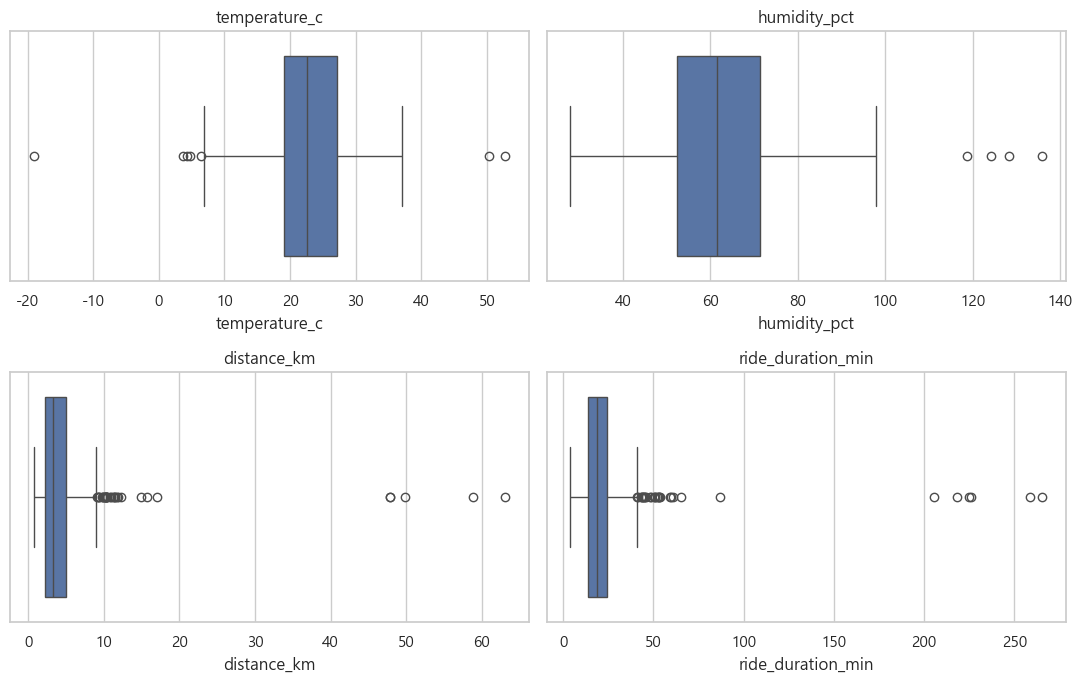

,lower,upper,outlier_count
temperature_c,6.700,39.500,7.0
humidity_pct,23.800,99.800,4.0
distance_km,-1.915,9.005,33.0
ride_duration_min,-2.750,40.850,31.0


이상치 플래그별 발생 건수:
humidity_range_error          4
temperature_c_outlier         7
distance_km_outlier          33
ride_duration_min_outlier    31
dtype: int64


In [3]:
outlier_cols = ["temperature_c", "humidity_pct", "distance_km", "ride_duration_min"]

# 3-1. 이상치 박스플롯 시각화 (스케일 차이 보완을 위해 2x2 subplot)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for col, ax in zip(outlier_cols, axes.flat):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# 3-2. IQR 하한, 상한 및 이상치 개수 계산
bounds = {}
for col in outlier_cols:
    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    bounds[col] = {"lower": lower, "upper": upper, "outlier_count": count}

display(pd.DataFrame(bounds).T)

# 3-3 & 3-4. 처리 전략 적용
# 습도(humidity_pct): 0~100% 범위를 벗어난 물리적 오류값이 존재하므로 Capping 처리 및 이상치 플래그 생성
df["humidity_range_error"] = (~df["humidity_pct"].between(0, 100)).astype("int8")
df["humidity_pct"] = df["humidity_pct"].clip(0, 100)

# 기온, 이동거리, 이용시간: 실제 일어날 수 있는 자연스러운 극단값이므로 값 변경 없이 이상치 플래그 생성
for col in ["temperature_c", "distance_km", "ride_duration_min"]:
    lower, upper, _ = iqr_bounds(df[col])
    df[f"{col}_outlier"] = ((df[col] < lower) | (df[col] > upper)).astype("int8")

print("이상치 플래그별 발생 건수:")
print(df[["humidity_range_error", "temperature_c_outlier", "distance_km_outlier", "ride_duration_min_outlier"]].sum())

In [4]:
# 4-1. 파생변수 생성
# 평균 속도 (km/h)
df["avg_speed_kmh"] = df["distance_km"].div(df["ride_duration_min"].div(60))
# 악천후 여부
df["bad_weather"] = df["weather"].eq("비").astype("int8")
# 노후 자전거 여부
df["old_bike"] = df["bike_age_months"].gt(df["bike_age_months"].median()).astype("int8")

# 이상 속도 확인 (시속 60km 이상 비현실적 데이터 플래그 생성)
df["speed_outlier"] = df["avg_speed_kmh"].gt(60).astype("int8")

# 4-2. 원-핫 인코딩 (EDA용 df는 보존하고 모델링용 model_df 별도 생성)
model_df = pd.get_dummies(df, columns=["station_zone", "member_type", "weather"], dtype="int8")

# 4-3. 스케일링 (late_return 및 식별자, 플래그 제외)
scale_cols = ["temperature_c", "humidity_pct", "wind_speed_mps", "distance_km",
              "ride_duration_min", "bike_age_months", "avg_speed_kmh"]

model_df[scale_cols] = StandardScaler().fit_transform(model_df[scale_cols])

# 4-4. Shape 비교 및 정제된 파일 저장
print(f"인코딩 전 shape: {df.shape}")
print(f"인코딩/스케일링 후 shape: {model_df.shape}")

model_df.to_csv("A_공유자전거_cleaned.csv", index=False)
print("A_공유자전거_cleaned.csv 저장 완료")

인코딩 전 shape: (644, 19)
인코딩/스케일링 후 shape: (644, 28)
A_공유자전거_cleaned.csv 저장 완료


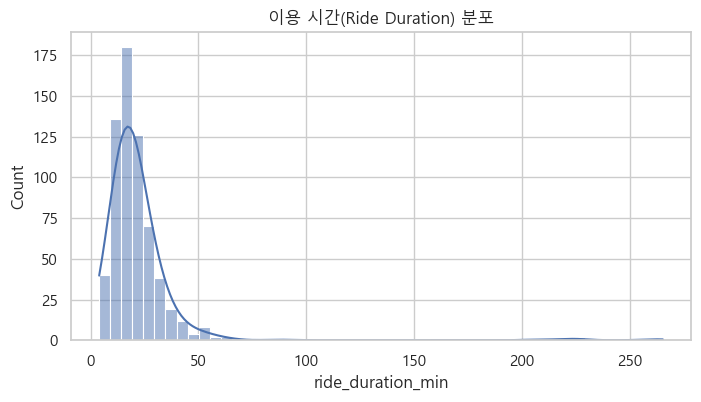

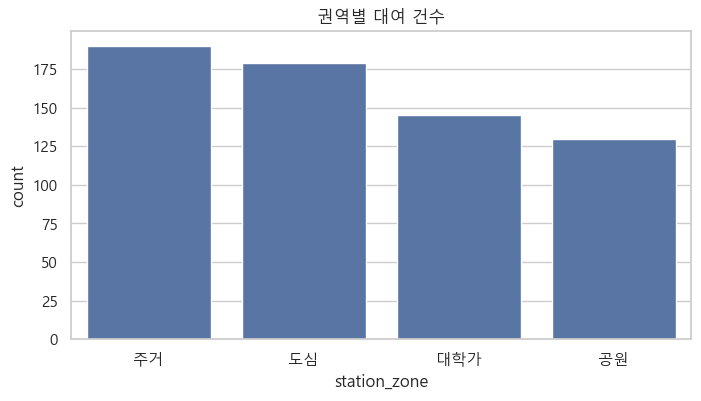

,count,ratio
late_return,,
0,613,0.951863
1,31,0.048137


In [5]:
# 5-1. ride_duration_min 분포
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="ride_duration_min", kde=True)
plt.title("이용 시간(Ride Duration) 분포")
plt.show()

# 5-2. station_zone 빈도
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="station_zone", order=df["station_zone"].value_counts().index)
plt.title("권역별 대여 건수")
plt.show()

# 5-3. late_return 빈도 및 비율
late_summary = df["late_return"].value_counts().to_frame("count")
late_summary["ratio"] = df["late_return"].value_counts(normalize=True)
display(late_summary)

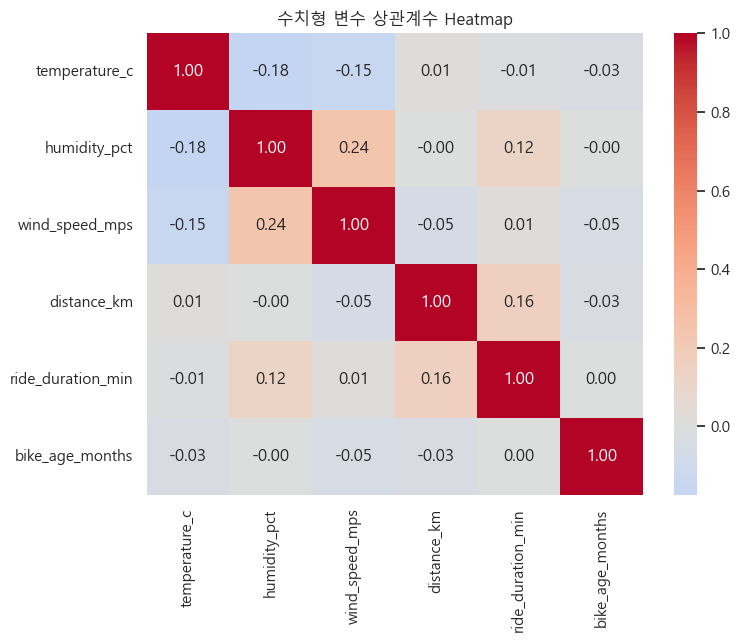

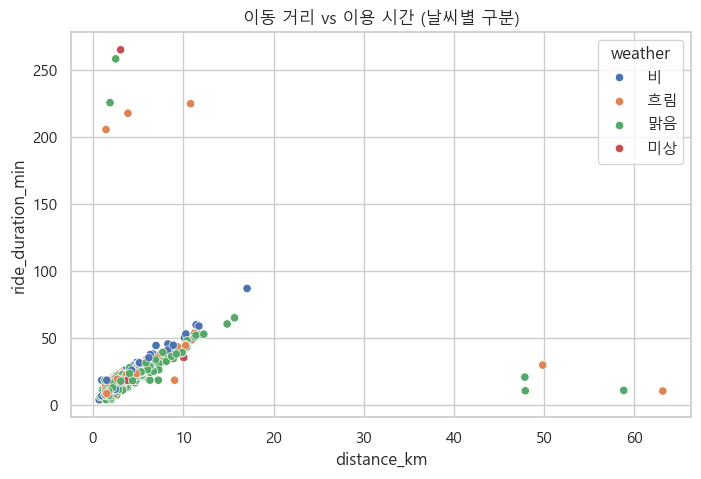

가장 높은 상관관계를 가지는 변수 쌍: ('humidity_pct', 'wind_speed_mps') (상관계수: 0.245)


In [6]:
# 6-1. 상관계수 히트맵 (파생변수 제외)
corr_cols = ["temperature_c", "humidity_pct", "wind_speed_mps", "distance_km", "ride_duration_min", "bike_age_months"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("수치형 변수 상관계수 Heatmap")
plt.show()

# 6-2. 이동거리 vs 이용시간 산점도 (날씨 구분)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="distance_km", y="ride_duration_min", hue="weather")
plt.title("이동 거리 vs 이용 시간 (날씨별 구분)")
plt.show()

# 6-3. 가장 높은 상관관계 변수 쌍 확인
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_pair = pairs.abs().idxmax()
print(f"가장 높은 상관관계를 가지는 변수 쌍: {top_pair} (상관계수: {corr.loc[top_pair]:.3f})")

In [7]:
highest_zone = zone_late["late_ratio"].idxmax()
highest_zone_ratio = zone_late.loc[highest_zone, "late_ratio"]

weather_stats = df.groupby("weather").agg(mean_duration=("ride_duration_min", "mean"))
longest_weather = weather_stats.drop(index="미상", errors="ignore")["mean_duration"].idxmax()
longest_weather_val = weather_stats.loc[longest_weather, "mean_duration"]

NameError: name 'zone_late' is not defined